In [1]:
import pickle
import os
import gpflow
import numpy as np
from tensorflow_probability import distributions as tfd
from s0_fun_base import XY_grw_nf_compu, XY_grw_f_compu, XY_grw_compu, XY_sur_compu, XY_fec_compu, XY_flow_compu
from s0_class_ABCPMC import ipmmcmc_whole
from s0_fun_IBMs import popu_structure, GPMC_posterior, IBM_1step_gp_cache, IBM_1step_gp_same_cache, IBM_1step_gp, IBM_1step_gp_same
f64 = gpflow.utilities.to_default_float
import matplotlib.pylab as plt
import pandas as pd
import bambi as bmb
from matplotlib.ticker import MaxNLocator

truedata_style='glm'
popu_dataset = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/"+truedata_style+"_mle_true_population.pkl", mode="rb"))
models_true = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/gp_"+truedata_style+"mle_mle_models.pkl", mode="rb"))
mle_models = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/gp_"+truedata_style+"mle_mle_models.pkl", mode="rb"))
glm_mle_true_models = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_models.pkl", mode="rb"))

samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))



whole_year = ipmmcmc_whole(popu_data=popu_dataset, grw_setting='sep', 
                            z0=popu_structure(popu_dataset), 
                            truedata_style=truedata_style, 
                            alpha=models_true['alpha'], beta=models_true['beta'], recruit_p=models_true['recruit_p'])

# Loading MCMC samples
# HMC for the other vital rates.
print('\n\n\n' + 'Processing: HMC' + '\n\n\n')

# Fec
df_fec = XY_fec_compu(popu_dataset)  
whole_year.m_fec_new = gpflow.models.GPMC(data=(df_fec[0], df_fec[1]), 
                               kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

whole_year.m_fec_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.m_fec_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.hmc_helper_fec = gpflow.optimizers.SamplingHelper(
    whole_year.m_fec_new.log_posterior_density, whole_year.m_fec_new.trainable_parameters
)

whole_year.samples_fec = samples_fec

# Flow poi
df_flow = XY_flow_compu(popu_dataset)  
whole_year.m_flow_poi_new =  gpflow.models.GPMC(data=(df_flow[0], df_flow[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Poisson())
whole_year.m_flow_poi_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.m_flow_poi_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.hmc_helper_flow = gpflow.optimizers.SamplingHelper(
    whole_year.m_flow_poi_new.log_posterior_density, whole_year.m_flow_poi_new.trainable_parameters
)

whole_year.samples_flow = samples_flow


# Grw_f
df_grw_f = XY_grw_f_compu(popu_dataset)    
whole_year.m_grw_f_new = gpflow.models.GPR(data=(df_grw_f[0], df_grw_f[1]), kernel=gpflow.kernels.RBF())
whole_year.m_grw_f_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.m_grw_f_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.m_grw_f_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.hmc_helper_grw_f = gpflow.optimizers.SamplingHelper(
    whole_year.m_grw_f_new.log_posterior_density, whole_year.m_grw_f_new.trainable_parameters
)

whole_year.samples_grw_f = samples_grw_f


# Grw_nf
df_grw_nf = XY_grw_nf_compu(popu_dataset)    
whole_year.m_grw_nf_new = gpflow.models.GPR(data=(df_grw_nf[0], df_grw_nf[1]), kernel=gpflow.kernels.RBF())
# we add priors to the hyperparameters.
whole_year.m_grw_nf_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.m_grw_nf_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.m_grw_nf_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
whole_year.hmc_helper_grw_nf = gpflow.optimizers.SamplingHelper(
    whole_year.m_grw_nf_new.log_posterior_density, whole_year.m_grw_nf_new.trainable_parameters
)

whole_year.samples_grw_nf = samples_grw_nf


# Sur
df_sur = XY_sur_compu(popu_dataset)  
whole_year.m_sur_new = gpflow.models.GPMC(data=(df_sur[0], df_sur[1]), 
                               kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

whole_year.m_sur_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(50.))
whole_year.m_sur_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(50.))
whole_year.hmc_helper_sur = gpflow.optimizers.SamplingHelper(
    whole_year.m_sur_new.log_posterior_density, whole_year.m_sur_new.trainable_parameters
)
whole_year.samples_sur = samples_sur





whole_year.rep = 1









Processing: HMC





In [2]:
# IPM Mesh setting
from s0_fun_IPMs import kernel_setting
lower_p = 0
upper_p = 5
m_size_p = 50
mesh_setting = kernel_setting(m_size_p, lower_p, upper_p)
Xp = mesh_setting[0]
step_size = m_size_p // 5
ticks = [i * step_size for i in range(0, 6)]
ticks[-1] = m_size_p - 1
repredict = False

In [3]:
# Loading GP results
if repredict == True:
    grw_pred =[]
    grw_f_pred =[] 
    grw_nf_pred =[] 
    fec_pred =[] 
    sur_pred =[] 
    flow_pred =[]  
    for iiiii in range(5000):
        whole_year.GPmodels_givenindex_cache([iiiii, iiiii, iiiii, iiiii, iiiii, iiiii])
        grw_pred.append(np.array(whole_year.m_grw_new.predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        grw_f_pred.append(np.array(whole_year.m_grw_f_new.predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        grw_nf_pred.append(np.array(whole_year.m_grw_nf_new.predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        flow_pred.append(np.array(whole_year.m_flow_poi_new.predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        fec_pred.append(np.array(whole_year.m_fec_new.predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        sur_pred.append(np.array(whole_year.m_sur_new.predict_y(Xp[:,None])[0]).reshape(1,-1)[0])

    # pickle.dump(grw_pred, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_pred.pkl", mode="wb"))
    pickle.dump(grw_f_pred, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_f_pred.pkl", mode="wb"))
    pickle.dump(grw_nf_pred, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_nf_pred.pkl", mode="wb"))
    pickle.dump(fec_pred, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/fec_pred.pkl", mode="wb"))
    pickle.dump(sur_pred, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/sur_pred.pkl", mode="wb"))
    pickle.dump(flow_pred, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/flow_pred.pkl", mode="wb")) 
else:
    # grw_pred = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_pred.pkl", mode="rb"))
    grw_f_pred = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_f_pred.pkl", mode="rb"))
    grw_nf_pred = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_nf_pred.pkl", mode="rb"))
    fec_pred = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/fec_pred.pkl", mode="rb"))
    sur_pred = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/sur_pred.pkl", mode="rb"))
    flow_pred = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/flow_pred.pkl", mode="rb"))


In [4]:
# Loading GLM results

truedata_style='glm'
grw_setting='sep'
model_type = 'glm'
glm_mle_true_population = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population/glm_mle_true_population.pkl", mode="rb"))
# Loading GLM MCMCs for glm datasets
globals()[f'trace_{truedata_style}data'] = {}
# trace_glmdata['trace_grw'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting2+"/trace_grw.pkl", mode="rb"))
globals()[f'trace_{truedata_style}data']['trace_grw_f'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_grw_f.pkl", mode="rb"))
globals()[f'trace_{truedata_style}data']['trace_grw_nf'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_grw_nf.pkl", mode="rb"))
globals()[f'trace_{truedata_style}data']['trace_fec'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_fec.pkl", mode="rb"))
globals()[f'trace_{truedata_style}data']['trace_flow'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_flow.pkl", mode="rb"))
globals()[f'trace_{truedata_style}data']['trace_sur'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_sur.pkl", mode="rb"))

globals()[f'model_{truedata_style}data'] = {}
df_grw_f = XY_grw_f_compu(globals()[f'{truedata_style}_mle_true_population'])
globals()[f'model_{truedata_style}data']['m_grw_f'] = bmb.Model("sizeNext ~ size", pd.concat(df_grw_f, axis=1))
# grw_nf
df_grw_nf = XY_grw_nf_compu(globals()[f'{truedata_style}_mle_true_population'])
globals()[f'model_{truedata_style}data']['m_grw_nf'] = bmb.Model("sizeNext ~ size", pd.concat(df_grw_nf, axis=1))
# sur
df_sur = XY_sur_compu(globals()[f'{truedata_style}_mle_true_population'])
globals()[f'model_{truedata_style}data']['m_sur'] = bmb.Model("sur ~ size", pd.concat(df_sur, axis=1), family='bernoulli')
# fec
df_fec = XY_fec_compu(globals()[f'{truedata_style}_mle_true_population'])
globals()[f'model_{truedata_style}data']['m_fec'] = bmb.Model("fec ~ size", pd.concat(df_fec, axis=1), family='bernoulli')
# flow
df_flow = XY_flow_compu(globals()[f'{truedata_style}_mle_true_population'])
globals()[f'model_{truedata_style}data']['m_flow_poi'] = bmb.Model("flow ~ size", pd.concat(df_flow, axis=1), family='poisson')
# recru
globals()[f'model_{truedata_style}data']['recruit_p'] = globals()[f'{truedata_style}_mle_true_models']['recruit_p']
globals()[f'model_{truedata_style}data']['alpha'] = globals()[f'{truedata_style}_mle_true_models']['alpha']
globals()[f'model_{truedata_style}data']['beta'] = globals()[f'{truedata_style}_mle_true_models']['beta']


glmpred_fec = model_glmdata['m_fec'].predict(trace_glmdata["trace_fec"], data=pd.DataFrame(Xp, columns=['size']), inplace=False)
glmpred_flow = model_glmdata['m_flow_poi'].predict(trace_glmdata["trace_flow"], data=pd.DataFrame(Xp, columns=['size']), inplace=False)
glmpred_sur = model_glmdata['m_sur'].predict(trace_glmdata["trace_sur"], data=pd.DataFrame(Xp, columns=['size']), inplace=False)
glmpred_grw_f = model_glmdata['m_grw_f'].predict(trace_glmdata["trace_grw_f"], data=pd.DataFrame(Xp, columns=['size']), inplace=False)
glmpred_grw_nf = model_glmdata['m_grw_nf'].predict(trace_glmdata["trace_grw_nf"], data=pd.DataFrame(Xp, columns=['size']), inplace=False)

In [5]:
# Loading GP ABC results at ending step
# #setting
truedata_style='glm'
grw_setting='sep'
model_type = 'gpabc'

if repredict == True:

    # Loading GP_abc results
    abc_index = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/p_index_6.pkl", mode="rb"))
    abc_weight = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/weight6.pkl", mode="rb"))
    #Loading data
    samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
    samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
    samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
    samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
    samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))

    popu_dataset = globals()[f'{truedata_style}_mle_true_population']

    # Fec
    df_fec = XY_fec_compu(popu_dataset)  
    m_fec_new = gpflow.models.GPMC(data=(df_fec[0], df_fec[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())
    m_fec_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_fec_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_fec = gpflow.optimizers.SamplingHelper(
        m_fec_new.log_posterior_density, m_fec_new.trainable_parameters
    )


    # Flow poi
    df_flow = XY_flow_compu(popu_dataset)  
    m_flow_poi_new =  gpflow.models.GPMC(data=(df_flow[0], df_flow[1]), 
                                    kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Poisson())
    m_flow_poi_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_flow_poi_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_flow = gpflow.optimizers.SamplingHelper(
        m_flow_poi_new.log_posterior_density, m_flow_poi_new.trainable_parameters
    )



    # Grw_f
    df_grw_f = XY_grw_f_compu(popu_dataset)    
    m_grw_f_new = gpflow.models.GPR(data=(df_grw_f[0], df_grw_f[1]), kernel=gpflow.kernels.RBF())
    m_grw_f_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_f = gpflow.optimizers.SamplingHelper(
        m_grw_f_new.log_posterior_density, m_grw_f_new.trainable_parameters
    )



    # Grw_nf
    df_grw_nf = XY_grw_nf_compu(popu_dataset)    
    m_grw_nf_new = gpflow.models.GPR(data=(df_grw_nf[0], df_grw_nf[1]), kernel=gpflow.kernels.RBF())
    m_grw_nf_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_nf = gpflow.optimizers.SamplingHelper(
        m_grw_nf_new.log_posterior_density, m_grw_nf_new.trainable_parameters
    )



    # Sur
    df_sur = XY_sur_compu(popu_dataset)  
    m_sur_new = gpflow.models.GPMC(data=(df_sur[0], df_sur[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

    m_sur_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(50.))
    m_sur_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(50.))
    hmc_helper_sur = gpflow.optimizers.SamplingHelper(
        m_sur_new.log_posterior_density, m_sur_new.trainable_parameters
    )

    grw_f_pred_abc =[]; grw_nf_pred_abc =[];  fec_pred_abc =[] ; sur_pred_abc =[];  flow_pred_abc =[]  
    np.random.seed(1234567)
    index = {}; diff_p = {}; diff_f = {}; growth_rate={}; stable = {}; repro = {}
    for i in range(5000):
        c_index = abc_index[np.random.choice(abc_weight.shape[0], p=abc_weight)]

        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[c_index[0]])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[c_index[1]])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[c_index[2]])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[c_index[3]])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[c_index[4]])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new,
            "alpha": globals()[f'{truedata_style}_mle_true_models']['alpha'],
            "beta": globals()[f'{truedata_style}_mle_true_models']['beta'],
            "recruit_p": globals()[f'{truedata_style}_mle_true_models']['recruit_p']
        }


        grw_f_pred_abc.append(np.array(models_now['m_grw_f'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        grw_nf_pred_abc.append(np.array(models_now['m_grw_nf'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        flow_pred_abc.append(np.array(models_now['m_flow_poi'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        fec_pred_abc.append(np.array(models_now['m_fec'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        sur_pred_abc.append(np.array(models_now['m_sur'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])

    pickle.dump(grw_f_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_f_pred_abc.pkl", mode="wb"))
    pickle.dump(grw_nf_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_nf_pred_abc.pkl", mode="wb"))
    pickle.dump(fec_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/fec_pred_abc.pkl", mode="wb"))
    pickle.dump(sur_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/sur_pred_abc.pkl", mode="wb"))
    pickle.dump(flow_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/flow_pred_abc.pkl", mode="wb"))


else:
    grw_f_pred_abc = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_f_pred_abc.pkl", mode="rb"))
    grw_nf_pred_abc = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_nf_pred_abc.pkl", mode="rb"))
    fec_pred_abc = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/fec_pred_abc.pkl", mode="rb"))
    sur_pred_abc = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/sur_pred_abc.pkl", mode="rb"))
    flow_pred_abc = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/flow_pred_abc.pkl", mode="rb"))



In [6]:
# Loading GP ABC results at previous step

if repredict == True:
    # Loading GP_abc results: with different index compared with the previous.
    abc_index = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/p_index_5.pkl", mode="rb"))
    abc_weight = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/weight5.pkl", mode="rb"))

    #Loading data
    samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
    samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
    samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
    samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
    samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))

    popu_dataset = globals()[f'{truedata_style}_mle_true_population']

    # Fec
    df_fec = XY_fec_compu(popu_dataset)  
    m_fec_new = gpflow.models.GPMC(data=(df_fec[0], df_fec[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())
    m_fec_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_fec_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_fec = gpflow.optimizers.SamplingHelper(
        m_fec_new.log_posterior_density, m_fec_new.trainable_parameters
    )


    # Flow poi
    df_flow = XY_flow_compu(popu_dataset)  
    m_flow_poi_new =  gpflow.models.GPMC(data=(df_flow[0], df_flow[1]), 
                                    kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Poisson())
    m_flow_poi_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_flow_poi_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_flow = gpflow.optimizers.SamplingHelper(
        m_flow_poi_new.log_posterior_density, m_flow_poi_new.trainable_parameters
    )



    # Grw_f
    df_grw_f = XY_grw_f_compu(popu_dataset)    
    m_grw_f_new = gpflow.models.GPR(data=(df_grw_f[0], df_grw_f[1]), kernel=gpflow.kernels.RBF())
    m_grw_f_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_f = gpflow.optimizers.SamplingHelper(
        m_grw_f_new.log_posterior_density, m_grw_f_new.trainable_parameters
    )



    # Grw_nf
    df_grw_nf = XY_grw_nf_compu(popu_dataset)    
    m_grw_nf_new = gpflow.models.GPR(data=(df_grw_nf[0], df_grw_nf[1]), kernel=gpflow.kernels.RBF())
    m_grw_nf_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_nf = gpflow.optimizers.SamplingHelper(
        m_grw_nf_new.log_posterior_density, m_grw_nf_new.trainable_parameters
    )



    # Sur
    df_sur = XY_sur_compu(popu_dataset)  
    m_sur_new = gpflow.models.GPMC(data=(df_sur[0], df_sur[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

    m_sur_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(50.))
    m_sur_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(50.))
    hmc_helper_sur = gpflow.optimizers.SamplingHelper(
        m_sur_new.log_posterior_density, m_sur_new.trainable_parameters
    )

    grw_f_pred_abc =[]; grw_nf_pred_abc =[];  fec_pred_abc =[] ; sur_pred_abc =[];  flow_pred_abc =[]  
    np.random.seed(1234567)
    index = {}; diff_p = {}; diff_f = {}; growth_rate={}; stable = {}; repro = {}
    for i in range(5000):
        c_index = abc_index[np.random.choice(abc_weight.shape[0], p=abc_weight)]

        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[c_index[0]])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[c_index[1]])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[c_index[2]])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[c_index[3]])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[c_index[4]])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new,
            "alpha": globals()[f'{truedata_style}_mle_true_models']['alpha'],
            "beta": globals()[f'{truedata_style}_mle_true_models']['beta'],
            "recruit_p": globals()[f'{truedata_style}_mle_true_models']['recruit_p']
        }


        grw_f_pred_abc.append(np.array(models_now['m_grw_f'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        grw_nf_pred_abc.append(np.array(models_now['m_grw_nf'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        flow_pred_abc.append(np.array(models_now['m_flow_poi'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        fec_pred_abc.append(np.array(models_now['m_fec'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])
        sur_pred_abc.append(np.array(models_now['m_sur'].predict_y(Xp[:,None])[0]).reshape(1,-1)[0])

    pickle.dump(grw_f_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_f_pred_abc2.pkl", mode="wb"))
    pickle.dump(grw_nf_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_nf_pred_abc2.pkl", mode="wb"))
    pickle.dump(fec_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/fec_pred_abc2.pkl", mode="wb"))
    pickle.dump(sur_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/sur_pred_abc2.pkl", mode="wb"))
    pickle.dump(flow_pred_abc, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/flow_pred_abc2.pkl", mode="wb"))
else:
    grw_f_pred_abc2 = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_f_pred_abc2.pkl", mode="rb"))
    grw_nf_pred_abc2 = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/grw_nf_pred_abc2.pkl", mode="rb"))
    fec_pred_abc2 = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/fec_pred_abc2.pkl", mode="rb"))
    sur_pred_abc2 = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/sur_pred_abc2.pkl", mode="rb"))
    flow_pred_abc2 = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/flow_pred_abc2.pkl", mode="rb"))

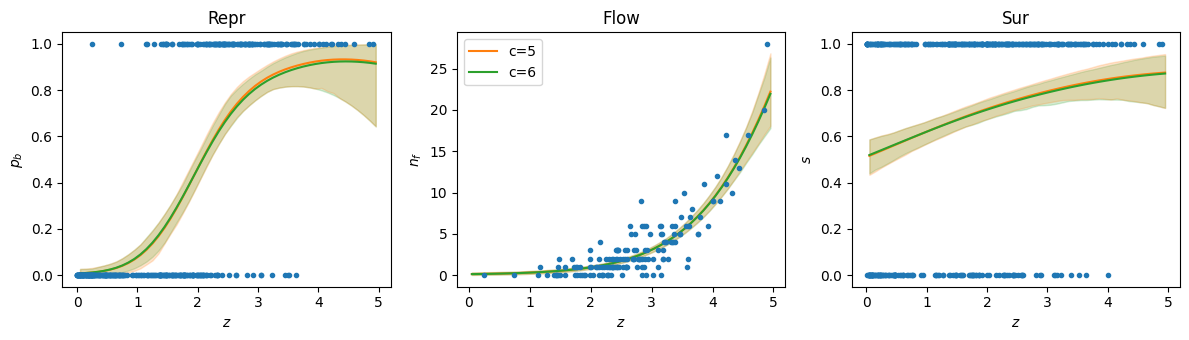

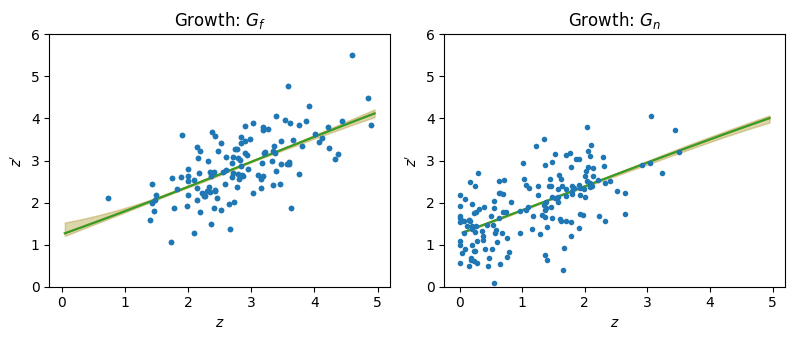

In [7]:
fig = plt.figure(figsize=(12, 3.5))

ax = fig.add_subplot(1, 3, 1)

plt.title('Repr')
plt.plot(Xp, np.mean(fec_pred_abc2, axis=0), color="C1", label='c=5')
plt.plot(Xp, np.mean(fec_pred_abc, axis=0), color="C2", label='c=6')
plt.fill_between(
    Xp, 
    np.quantile(fec_pred_abc, 0.025, axis=0), 
    np.quantile(fec_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C2"
)
plt.fill_between(
    Xp, 
    np.quantile(fec_pred_abc2, 0.025, axis=0), 
    np.quantile(fec_pred_abc2, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_fec[0][df_fec[0]>0], df_fec[1], '.', color='C0')
plt.ylabel('$p_b$')
plt.xlabel("$z$")

ax = fig.add_subplot(1, 3, 2)
plt.title('Flow')
plt.plot(Xp, np.mean(flow_pred_abc2, axis=0), color="C1", label='c=5')
plt.plot(Xp, np.mean(flow_pred_abc, axis=0), color="C2", label='c=6')
plt.fill_between(
    Xp, 
    np.quantile(flow_pred_abc, 0.025, axis=0), 
    np.quantile(flow_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C2"
)
plt.fill_between(
    Xp, 
    np.quantile(flow_pred_abc2, 0.025, axis=0), 
    np.quantile(flow_pred_abc2, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_flow[0][df_flow[0]>0], df_flow[1], '.', color='C0')
plt.legend()
plt.ylabel('$n_f$')
plt.xlabel("$z$")

ax = fig.add_subplot(1, 3, 3)
plt.title('Sur')
plt.plot(Xp, np.mean(sur_pred_abc2, axis=0), color="C1", label='gp_abc_mean')
plt.plot(Xp, np.mean(sur_pred_abc, axis=0), color="C2", label='gp_abc_mean')
plt.fill_between(
    Xp, 
    np.quantile(sur_pred_abc, 0.025, axis=0), 
    np.quantile(sur_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C2"
)
plt.fill_between(
    Xp, 
    np.quantile(sur_pred_abc2, 0.025, axis=0), 
    np.quantile(sur_pred_abc2, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_sur[0][df_sur[0]>0], df_sur[1], '.', color='C0')
plt.ylabel('$s$')
plt.xlabel("$z$")
plt.tight_layout()


# plt.savefig('glm_sep_step5vs6.pdf')  
plt.show()
fig = plt.figure(figsize=(12, 3.5))
ax = fig.add_subplot(1, 3, 1)
plt.title('Growth: $G_f$')
plt.plot(Xp, np.mean(grw_f_pred_abc2, axis=0), color="C1", label='ABC_GP')
plt.plot(Xp, np.mean(grw_f_pred_abc, axis=0), color="C2", label='ABC_GP')
plt.fill_between(
    Xp, 
    np.quantile(grw_f_pred_abc, 0.025, axis=0), 
    np.quantile(grw_f_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C2"
)
plt.plot(df_grw_f[0][df_grw_f[0]>0], df_grw_f[1], '.', color='C0')
plt.fill_between(
    Xp, 
    np.quantile(grw_f_pred_abc2, 0.025, axis=0), 
    np.quantile(grw_f_pred_abc2, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_grw_f[0][df_grw_f[0]>0], df_grw_f[1], '.', color='C0')
plt.ylabel("$z'$")
plt.xlabel("$z$")
plt.ylim(0, 6)
ax = fig.add_subplot(1, 3, 2)
plt.title('Growth: $G_n$')
plt.plot(Xp, np.mean(grw_nf_pred_abc2, axis=0), color="C1", label='gp_abc_mean')

plt.plot(Xp, np.mean(grw_nf_pred_abc, axis=0), color="C2", label='gp_abc_mean')
plt.fill_between(
    Xp, 
    np.quantile(grw_nf_pred_abc, 0.025, axis=0), 
    np.quantile(grw_nf_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C2"
)
plt.fill_between(
    Xp, 
    np.quantile(grw_nf_pred_abc2, 0.025, axis=0), 
    np.quantile(grw_nf_pred_abc2, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_grw_nf[0][df_grw_nf[0]>0], df_grw_nf[1], '.', color='C0')
plt.ylabel("$z'$")
plt.xlabel("$z$")
plt.ylim(0, 6)


plt.tight_layout()
# plt.savefig('glm_sep_step5vs6_2.pdf')  

plt.show()




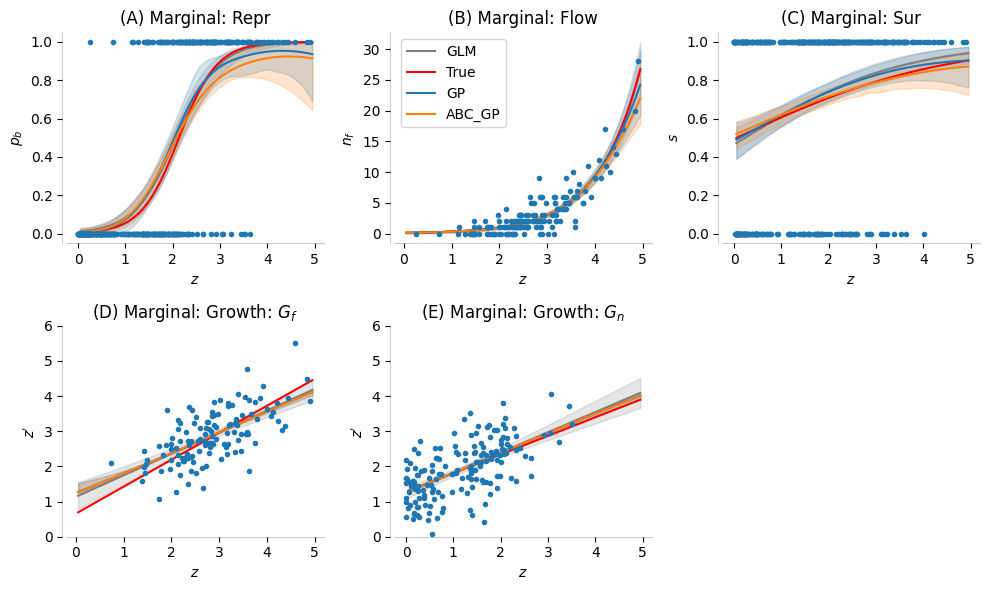

In [8]:
fig = plt.figure(figsize=(10, 6))


ax = fig.add_subplot(2, 3, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(A) Marginal: Repr')
plt.plot(Xp, np.mean(glmpred_fec.posterior['fec_mean'].values[0], axis=0), color="C7", label='GLM')
plt.plot(Xp, glm_mle_true_models['m_fec'].predict(pd.DataFrame(Xp, columns=['size'])), color="red",label='True')
plt.fill_between(
    Xp,
    np.quantile(glmpred_fec.posterior['fec_mean'].values[0], 0.025, axis=0), 
    np.quantile(glmpred_fec.posterior['fec_mean'].values[0], 0.975, axis=0),
    alpha=0.2, color="C7"
)
plt.plot(Xp, np.mean(fec_pred, axis=0), color="C0", label='GP')
plt.fill_between(
    Xp, 
    np.quantile(fec_pred, 0.025, axis=0), 
    np.quantile(fec_pred, 0.975, axis=0),
    alpha=0.2, color="C0"
)
plt.plot(Xp, np.mean(fec_pred_abc, axis=0), color="C1", label='ABC_GP')
plt.fill_between(
    Xp, 
    np.quantile(fec_pred_abc, 0.025, axis=0), 
    np.quantile(fec_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_fec[0][df_fec[0]>0], df_fec[1], '.', color='C0')
plt.ylabel('$p_b$')
plt.xlabel("$z$")

ax = fig.add_subplot(2, 3, 2)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(B) Marginal: Flow')
plt.plot(Xp, np.mean(glmpred_flow.posterior['flow_mean'].values[0], axis=0), color="C7", label='GLM')
plt.plot(Xp, glm_mle_true_models['m_flow_poi'].predict(pd.DataFrame(Xp, columns=['size'])), color="red",label='True')
plt.fill_between(
    Xp, 
    np.quantile(glmpred_flow.posterior['flow_mean'].values[0], 0.025, axis=0), 
    np.quantile(glmpred_flow.posterior['flow_mean'].values[0], 0.975, axis=0),
    alpha=0.2, color="C7"
)
plt.plot(Xp, np.mean(flow_pred, axis=0), color="C0", label='GP')
plt.fill_between(
    Xp, 
    np.quantile(flow_pred, 0.025, axis=0), 
    np.quantile(flow_pred, 0.975, axis=0),
    alpha=0.2, color="C0"
)
plt.plot(Xp, np.mean(flow_pred_abc, axis=0), color="C1", label='ABC_GP')
plt.fill_between(
    Xp, 
    np.quantile(flow_pred_abc, 0.025, axis=0), 
    np.quantile(flow_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_flow[0][df_flow[0]>0], df_flow[1], '.', color='C0')
plt.legend()
plt.ylabel('$n_f$')
plt.xlabel("$z$")

ax = fig.add_subplot(2, 3, 3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(C) Marginal: Sur')
plt.plot(Xp, np.mean(glmpred_sur.posterior['sur_mean'].values[0], axis=0), color="C7", label='GLM')
plt.plot(Xp, glm_mle_true_models['m_sur'].predict(pd.DataFrame(Xp, columns=['size'])), color="red",label='True')
plt.fill_between(
    Xp, 
    np.quantile(glmpred_sur.posterior['sur_mean'].values[0], 0.025, axis=0), 
    np.quantile(glmpred_sur.posterior['sur_mean'].values[0], 0.975, axis=0),
    alpha=0.2, color="C7"
)
plt.plot(Xp, np.mean(sur_pred, axis=0), color="C0", label='GP')
plt.fill_between(
    Xp, 
    np.quantile(sur_pred, 0.025, axis=0), 
    np.quantile(sur_pred, 0.975, axis=0),
    alpha=0.2, color="C0"
)
plt.plot(Xp, np.mean(sur_pred_abc, axis=0), color="C1", label='ABC_GP')
plt.fill_between(
    Xp, 
    np.quantile(sur_pred_abc, 0.025, axis=0), 
    np.quantile(sur_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_sur[0][df_sur[0]>0], df_sur[1], '.', color='C0')
plt.ylabel('$s$')
plt.xlabel("$z$")


ax = fig.add_subplot(2, 3, 4)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(D) Marginal: Growth: $G_f$')
plt.plot(Xp, np.mean(glmpred_grw_f.posterior['sizeNext_mean'].values[0], axis=0), color="C7", label='GLM')
plt.plot(Xp, glm_mle_true_models['m_grw_f'].predict(pd.DataFrame(Xp, columns=['size'])), color="red",label='True')
plt.fill_between(
    Xp, 
    np.quantile(glmpred_grw_f.posterior['sizeNext_mean'].values[0], 0.025, axis=0), 
    np.quantile(glmpred_grw_f.posterior['sizeNext_mean'].values[0], 0.975, axis=0),
    alpha=0.2, color="C7"
)
plt.plot(Xp, np.mean(grw_f_pred, axis=0), color="C0", label='GP')
plt.fill_between(
    Xp, 
    np.quantile(grw_f_pred, 0.025, axis=0), 
    np.quantile(grw_f_pred, 0.975, axis=0),
    alpha=0.2, color="C0"
)
plt.plot(Xp, np.mean(grw_f_pred_abc, axis=0), color="C1", label='ABC_GP')
plt.fill_between(
    Xp, 
    np.quantile(grw_f_pred_abc, 0.025, axis=0), 
    np.quantile(grw_f_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_grw_f[0][df_grw_f[0]>0], df_grw_f[1], '.', color='C0')
plt.ylabel("$z'$")
plt.xlabel("$z$")
plt.ylim(0, 6)

ax = fig.add_subplot(2, 3, 5)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(E) Marginal: Growth: $G_n$')
plt.plot(Xp, np.mean(glmpred_grw_nf.posterior['sizeNext_mean'].values[0], axis=0), color="C7", label='GLM')
plt.plot(Xp, glm_mle_true_models['m_grw_nf'].predict(pd.DataFrame(Xp, columns=['size'])), color="red",label='True')
plt.fill_between(
    Xp, 
    np.quantile(glmpred_grw_nf.posterior['sizeNext_mean'].values[0], 0.025, axis=0), 
    np.quantile(glmpred_grw_nf.posterior['sizeNext_mean'].values[0], 0.975, axis=0),
    alpha=0.2, color="C7"
)
plt.plot(Xp, np.mean(grw_nf_pred, axis=0), color="C0", label='GP')
plt.fill_between(
    Xp, 
    np.quantile(grw_nf_pred, 0.025, axis=0), 
    np.quantile(grw_nf_pred, 0.975, axis=0),
    alpha=0.2, color="C0"
)
plt.plot(Xp, np.mean(grw_nf_pred_abc, axis=0), color="C1", label='ABC_GP')
plt.fill_between(
    Xp, 
    np.quantile(grw_nf_pred_abc, 0.025, axis=0), 
    np.quantile(grw_nf_pred_abc, 0.975, axis=0),
    alpha=0.2, color="C1"
)
plt.plot(df_grw_nf[0][df_grw_nf[0]>0], df_grw_nf[1], '.', color='C0')
plt.ylabel("$z'$")
plt.xlabel("$z$")
plt.ylim(0, 6)


plt.tight_layout()
# plt.savefig('plot11113.pdf')  
plt.show()


In [8]:
fec_true = glm_mle_true_models['m_fec'].predict(pd.DataFrame(Xp, columns=['size']))
sur_true = glm_mle_true_models['m_sur'].predict(pd.DataFrame(Xp, columns=['size']))
flow_true = glm_mle_true_models['m_flow_poi'].predict(pd.DataFrame(Xp, columns=['size']))
grw_f_true = glm_mle_true_models['m_grw_nf'].predict(pd.DataFrame(Xp, columns=['size']))
grw_nf_true = glm_mle_true_models['m_grw_nf'].predict(pd.DataFrame(Xp, columns=['size']))

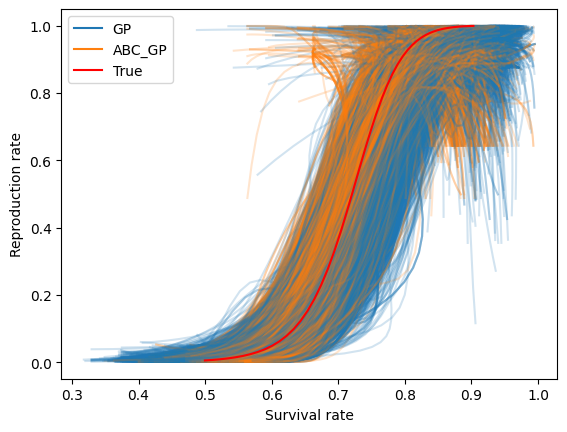

In [11]:


plt.plot(sur_pred[0], fec_pred[0], color='C0', label='GP')
plt.plot(sur_pred_abc[0], fec_pred_abc[0], color='C1', label='ABC_GP')


for i in range(0, 5000):
    plt.plot(sur_pred[i], fec_pred[i], color='C0', alpha=0.2)
    plt.plot(sur_pred_abc[i], fec_pred_abc[i], color='C1', alpha=0.2)

plt.plot(sur_true, fec_true, color='red', label='True')

plt.xlabel("Survival rate")
plt.ylabel("Reproduction rate")
plt.legend()
# axs[0, 0].set_title("Survival vs Reproduction")

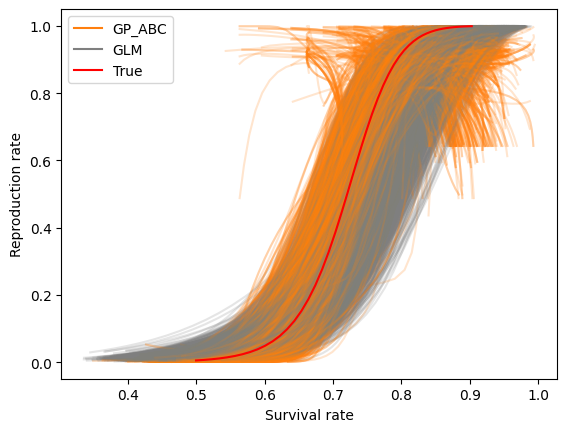

In [14]:


plt.plot(sur_pred_abc[0], fec_pred_abc[0], color='C1', label='GP_ABC')
plt.plot(glmpred_sur.posterior['sur_mean'].values[0][0],
         glmpred_fec.posterior['fec_mean'].values[0][0], color='C7', label='GLM')


for i in range(0, 5000):
    plt.plot(sur_pred_abc[i], fec_pred_abc[i], color='C1', alpha=0.2)
    plt.plot(glmpred_sur.posterior['sur_mean'].values[0][i],
             glmpred_fec.posterior['fec_mean'].values[0][i], color='C7', alpha=0.2)

plt.plot(sur_true, fec_true, color='red', label='True')

plt.xlabel("Survival rate")
plt.ylabel("Reproduction rate")
plt.legend()
# axs[0, 0].set_title("Survival vs Reproduction")

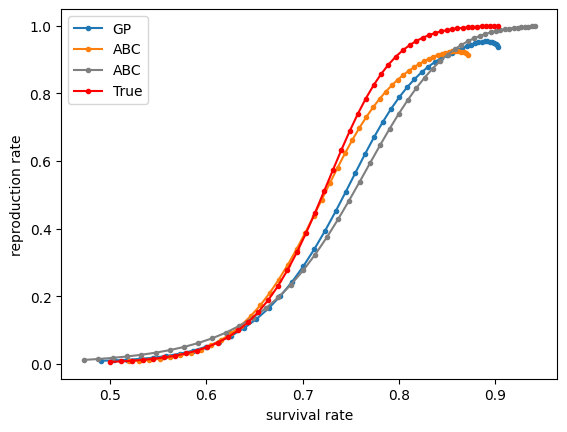

In [13]:
plt.plot(np.mean(sur_pred, axis=0),  np.mean(fec_pred, axis=0), '.-',color='C0', label='GP')
plt.plot(np.mean(sur_pred_abc, axis=0),  np.mean(fec_pred_abc, axis=0), '.-', color='C1', label='ABC')
plt.plot(np.mean(glmpred_sur.posterior['sur_mean'].values[0], axis=0),  
         np.mean(glmpred_fec.posterior['fec_mean'].values[0], axis=0), '.-', color='C7', label='ABC')

plt.plot(sur_true,  fec_true, '.-', color='red', label='True')
plt.xlabel("survival rate")
plt.ylabel("reproduction rate")
plt.legend()

/var/folders/j0/_y_32zn92zz8gd3515l_d0sw0000gn/T/ipykernel_56053/3480779819.py:71: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


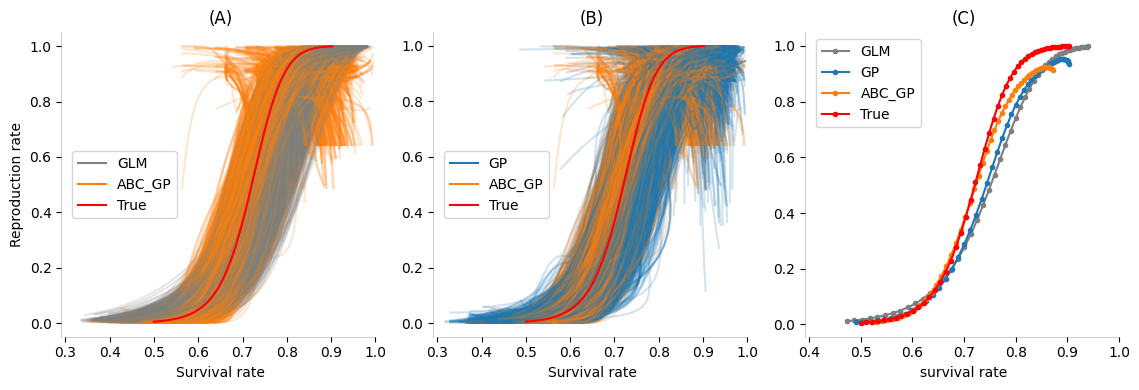

In [15]:
fig = plt.figure(figsize=(11.5, 4))


ax = fig.add_subplot(1, 3, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(A)')
plt.plot(glmpred_sur.posterior['sur_mean'].values[0][0],
         glmpred_fec.posterior['fec_mean'].values[0][0], color='C7', label='GLM')

plt.plot(sur_pred_abc[0], fec_pred_abc[0], color='C1', label='ABC_GP')


for i in range(0, 5000):
    plt.plot(sur_pred_abc[i], fec_pred_abc[i], color='C1', alpha=0.2)
    plt.plot(glmpred_sur.posterior['sur_mean'].values[0][i],
             glmpred_fec.posterior['fec_mean'].values[0][i], color='C7', alpha=0.2)

plt.plot(sur_true, fec_true, color='red', label='True')
plt.legend()
plt.xlabel("Survival rate")
plt.ylabel("Reproduction rate")
plt.xlim(0.3, 1.0)
plt.xticks(np.arange(0.3, 1.01, 0.1))
# plt.legend()
# axs[0, 0].set_title("Survival vs Reproduction")


ax = fig.add_subplot(1, 3, 2)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(B)')


plt.plot(sur_pred[0], fec_pred[0], color='C0', label='GP')
plt.plot(sur_pred_abc[0], fec_pred_abc[0], color='C1', label='ABC_GP')


for i in range(0, 5000):
    plt.plot(sur_pred[i], fec_pred[i], color='C0', alpha=0.2)
    plt.plot(sur_pred_abc[i], fec_pred_abc[i], color='C1', alpha=0.2)

plt.plot(sur_true, fec_true, color='red', label='True')
plt.legend()
plt.xlim(0.3, 1.0)
plt.xticks(np.arange(0.3, 1.01, 0.1))
plt.xlabel("Survival rate")
# plt.ylabel("Reproduction rate")
# plt.legend()
# axs[0, 0].set_title("Survival vs Reproduction")

ax = fig.add_subplot(1, 3, 3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(C)')

plt.plot(np.mean(glmpred_sur.posterior['sur_mean'].values[0], axis=0),  
         np.mean(glmpred_fec.posterior['fec_mean'].values[0], axis=0), '.-', color='C7', label='GLM')
plt.plot(np.mean(sur_pred, axis=0),  np.mean(fec_pred, axis=0), '.-',color='C0', label='GP')
plt.plot(np.mean(sur_pred_abc, axis=0),  np.mean(fec_pred_abc, axis=0), '.-', color='C1', label='ABC_GP')
plt.plot(sur_true,  fec_true, '.-', color='red', label='True')
plt.xlabel("survival rate")
plt.xlim(0.4, 1.0)
plt.xticks(np.arange(0.4, 1.01, 0.1))
# plt.ylabel("reproduction rate")
plt.legend()

plt.tight_layout()
plt.savefig('plot_interaction.pdf')  
plt.show()

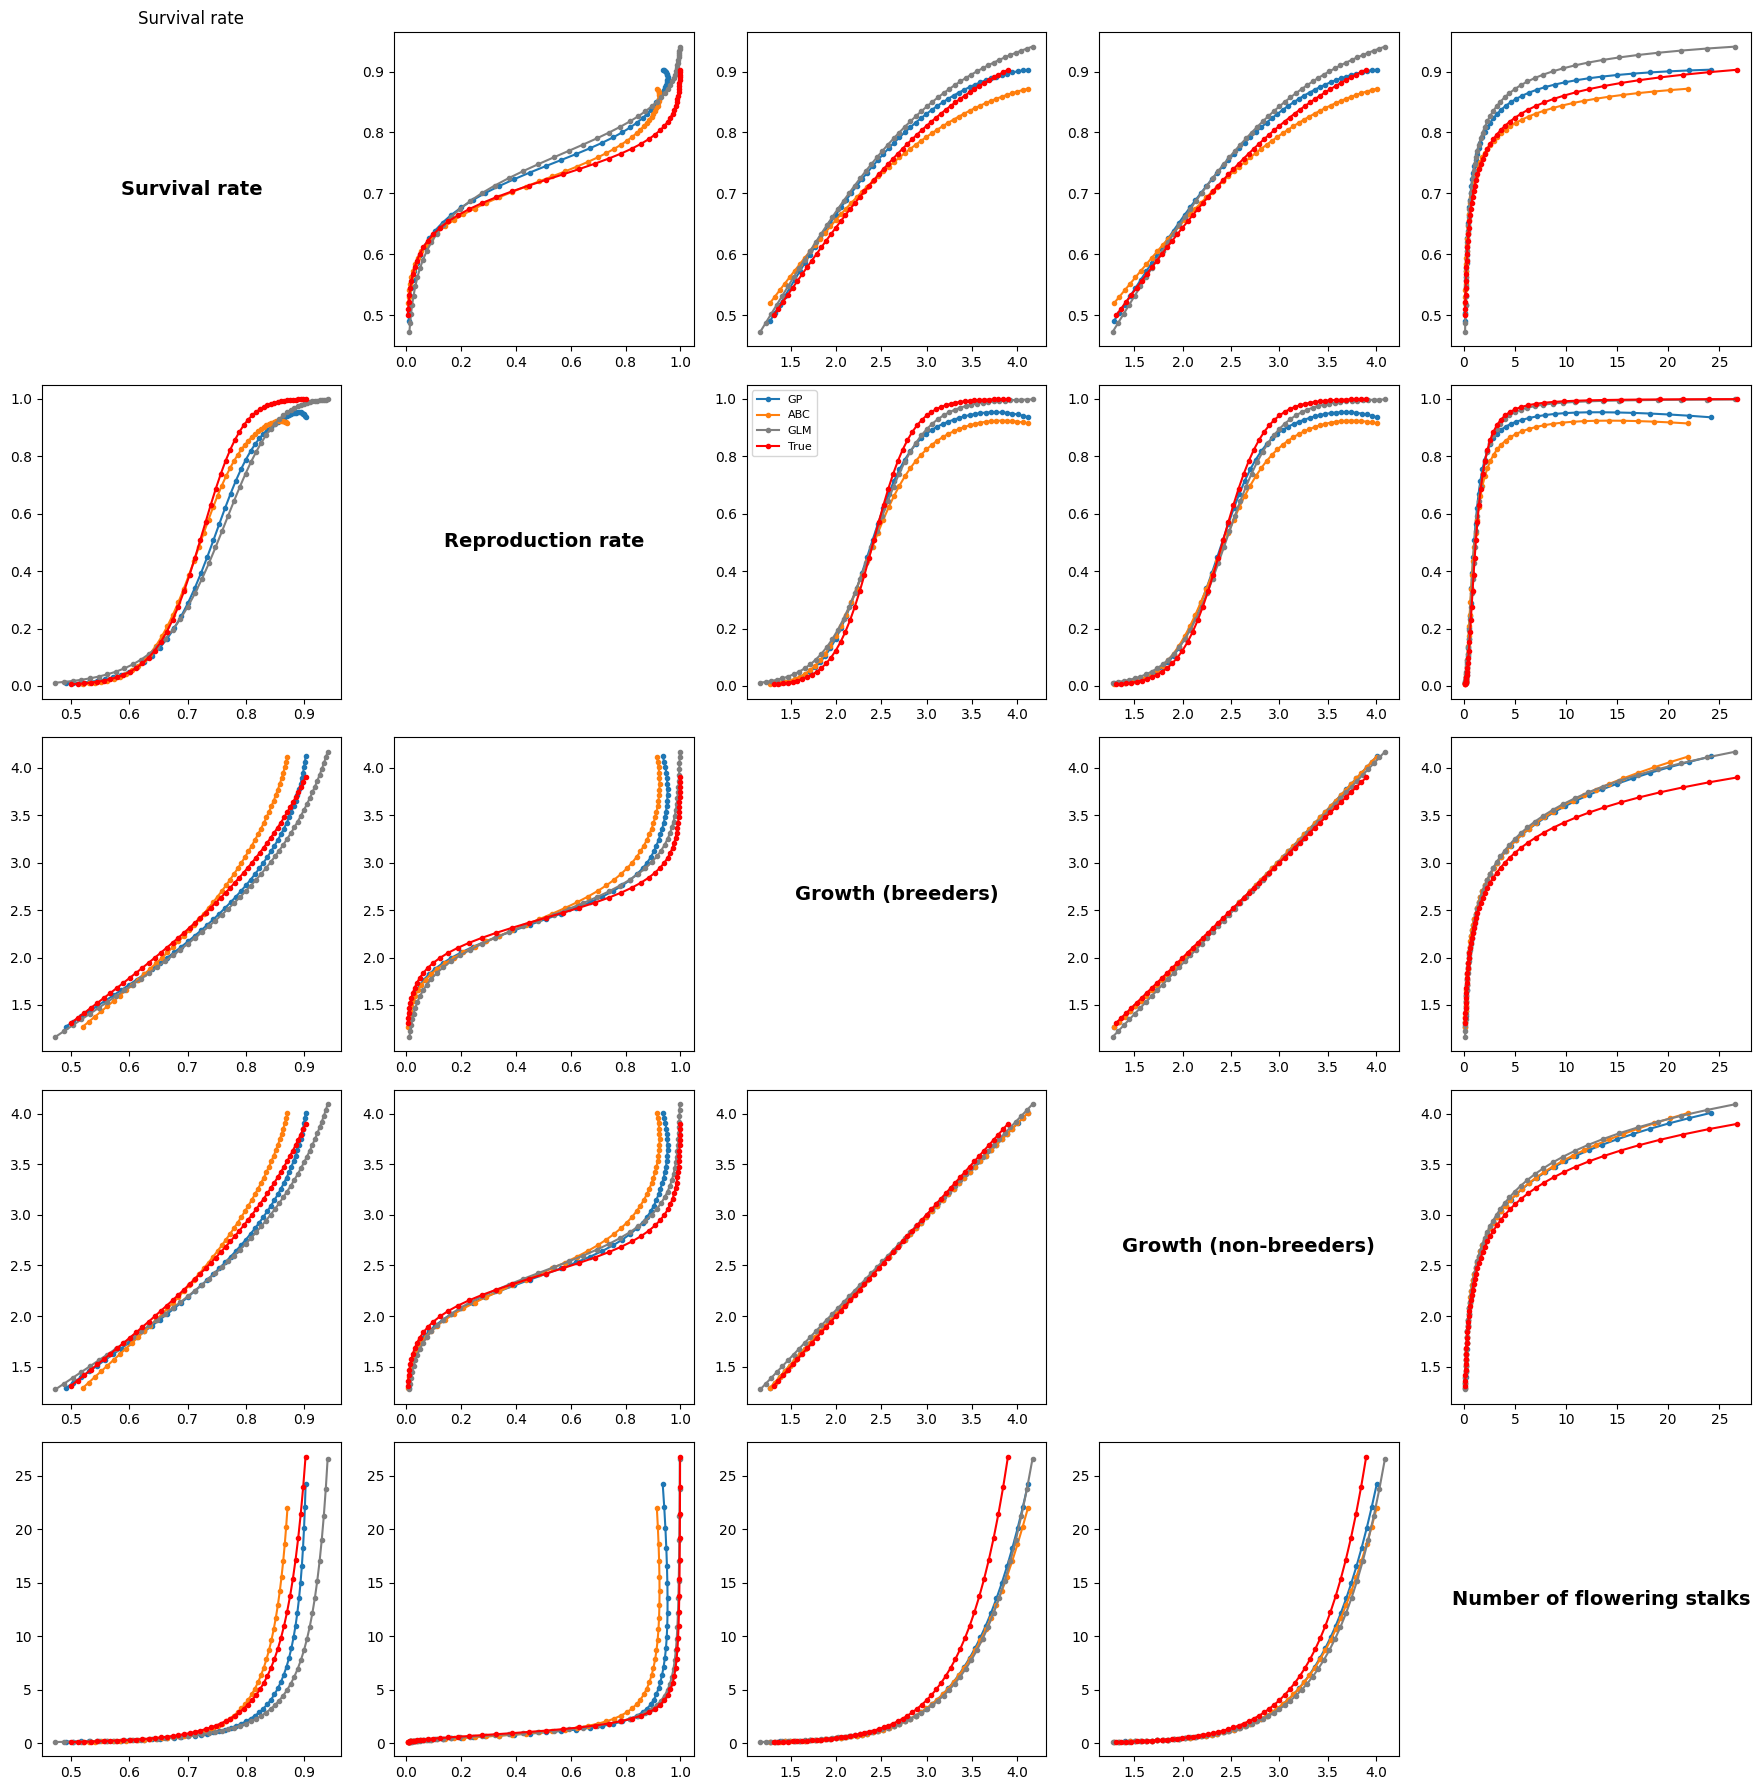

In [16]:
# Diagram plot: all pairwise relationships between [sur, fec, grw_f, grw_nf, flow]
# Each subplot: x vs y, where x and y are from [sur, fec, grw_f, grw_nf, flow], x != y

var_names = ['sur', 'fec', 'grw_f', 'grw_nf', 'flow']
pred_gp = [np.mean(sur_pred, axis=0), np.mean(fec_pred, axis=0), np.mean(grw_f_pred, axis=0), np.mean(grw_nf_pred, axis=0), np.mean(flow_pred, axis=0)]
pred_abc = [np.mean(sur_pred_abc, axis=0), np.mean(fec_pred_abc, axis=0), np.mean(grw_f_pred_abc, axis=0), np.mean(grw_nf_pred_abc, axis=0), np.mean(flow_pred_abc, axis=0)]
pred_glm = [
    np.mean(glmpred_sur.posterior['sur_mean'].values[0], axis=0),
    np.mean(glmpred_fec.posterior['fec_mean'].values[0], axis=0),
    np.mean(glmpred_grw_f.posterior['sizeNext_mean'].values[0], axis=0),
    np.mean(glmpred_grw_nf.posterior['sizeNext_mean'].values[0], axis=0),
    np.mean(glmpred_flow.posterior['flow_mean'].values[0], axis=0)
]
true_vals = [sur_true, fec_true, grw_f_true, grw_nf_true, flow_true]
labels = ["Survival rate", "Reproduction rate", "Growth (breeders)", "Growth (non-breeders)", "Number of flowering stalks"]

fig, axs = plt.subplots(5, 5, figsize=(18, 18))
for i in range(5):
    for j in range(5):
        ax = axs[i, j]
        if i == j:
            ax.axis('off')
            # Add variable name in the center of the empty subplot
            ax.text(0.5, 0.5, labels[i], ha='center', va='center', fontsize=14, fontweight='bold', color='black', transform=ax.transAxes)
            if i == 0:
                ax.set_title(labels[j])
            if j == 0:
                ax.set_ylabel(labels[i])
            continue
        # GP
        ax.plot(pred_gp[j], pred_gp[i], '.-', color='C0', label='GP')
        # ABC
        ax.plot(pred_abc[j], pred_abc[i], '.-', color='C1', label='ABC')
        # GLM
        ax.plot(pred_glm[j], pred_glm[i], '.-', color='C7', label='GLM')
        # True
        ax.plot(true_vals[j], true_vals[i], '.-', color='red', label='True')
        # if i == 0:
            # ax.set_title(labels[j])
        # if j == 0:
            # ax.set_ylabel(labels[i])
        if i == 1 and j == 2:
            ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()